<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_11_desicion_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 11: Árboles de desición


#Algoritmo CART (classification and regresion tree)

Se busca entrenar un modelo para categorizar la información encontrando la frontera de desición, permite tener una mejor interpretabilidad que las redes neuronales dado que se puede tener una represetancion grafica del proceso de desiscion secuencial.

- ref https://www.youtube.com/watch?v=kqaLlte6P6o&ab_channel=CodificandoBits
- Hand on Machine leargning 




Dado un conjunto de caracteristicas se establece una condición que realiza 
una particion binaria de los datos a clasificar repitiendo hasta encontrar 
particiones lo más homogenea posible.




Text(0, 0.5, '$X_2$')

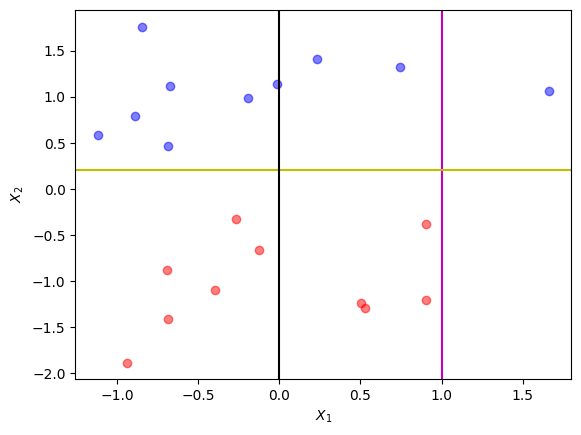

In [2]:
X0, y0 = make_classification(n_samples=20,
    n_features=2, n_redundant=0, n_informative=1, random_state=1, 
    n_clusters_per_class=1)

x=np.arange(-2, 3,1)
x_,y_ = np.meshgrid(x,x)

fig, ax = plt.subplots()
ax.plot(X0[:,0][y0==0],X0[:,1][y0==0],"ro", alpha=0.5)
ax.plot(X0[:,0][y0==1],X0[:,1][y0==1],"bo", alpha=0.5)
#ax.plot(x_,y_,"k.")

ax.axvline(x = 1, color = 'm', label="x1<=1")
ax.axhline(y = 0.2, color = 'y', label="x2<0.2")
ax.axvline(x = 0.0, color = 'k', label="x2<0.2")
#plt.legend(loc=3)
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")


- Gini index


$G = 1 - (PC_1)^2 - (PC_2)^2$

$PC_1$: Probablidad categoria 1 

$PC_2$: Probablidad categoria 2 

Si :

- $G=0$ nodos puros, datos que pertenecen a una sola categoría

- Gini > 0 son nodos con impurezas, con mas de una categoría


La partición purpura  y amarilla del gráfico anterior representan nodos puros.

Mientras que la linea negra define:

- 7 puntos son de color azul.

- 6 puntos de color rojo.

$G = 1 - (7/13)^{2} - (6/13)^{2}$

mientrás que la ponderacion viene dada por:

$m = (7/20+7/20)=7/10$



No:

$G=1-(3/7)^{2}-(4/7)^{2}$
m = (3/20+4/20)


La funcion de coste, asocida al nodo padre:

$J(k, t_k) = \frac{m_{left}}{m} G_{left} + \frac{m_{right}}{m} G_{right} $



# Algoritmo
1. Calcular todos los posibles condiciones. 
2. Calcular los indices de Gini.
3. Encontrar la funcion de coste 
4. Escoger la menor funcion de coste 
5. Repetir.



1. Importar iris dataset 
2. Generar una intuición respecto a iris dataset. Ver laboratorio anterior.
3. Dividir el *dataset* empleanto el metodo train_test_split de sklearn
4. Dentro de sklearn, aplicar el algoritmo DecisionTreeClassifier.
5. Para el clasificador analice el gráfico de desición:

```

https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html

  fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
  graph=tree.plot_tree(clf,class_names = iris.target_names,\
                feature_names = iris.feature_names,\
                impurity=False, filled=True,rounded=True )

```

6. Características importantes.

```
clf.feature_importances_
caract = iris.data.shape[1]
plt.barh(range(caract), clf.feature_importances_)
plt.yticks(np.arange(caract),iris.feature_names)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.show()
```

7. Fronteras de desición.



```
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# Parameters
n_classes = 3
plot_colors = "bry"
plot_step = 0.02

# Load data
iris = load_iris()

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],
                                [1, 2], [1, 3], [2, 3]]):
    # We only take the two corresponding features
    X = iris.data[:, pair]
    y = iris.target

    # Shuffle
    idx = np.arange(X.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)
    X = X[idx]
    y = y[idx]

    # Standardize
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X = (X - mean) / std

    # Train
    clf = DecisionTreeClassifier().fit(X, y)

    # Plot the decision boundary
    plt.subplot(2, 3, pairidx + 1)
  
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])
    plt.axis("tight")

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
                    cmap=plt.cm.Paired)

    plt.axis("tight")

plt.suptitle("Decision surface of a decision tree using paired features")
plt.legend()
plt.show()
```


# Desarrollo

Jhonatan Jurado Rodríguez

In [1]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pylab as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
import graphviz
#from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree


In [3]:

# ── 1. Cargar dataset Iris ────────────────────────────────────────────────────
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print("Forma del dataset:", X_iris.shape)
print("Clases:", iris.target_names)
print("Características:", iris.feature_names)


Forma del dataset: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']
Características: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


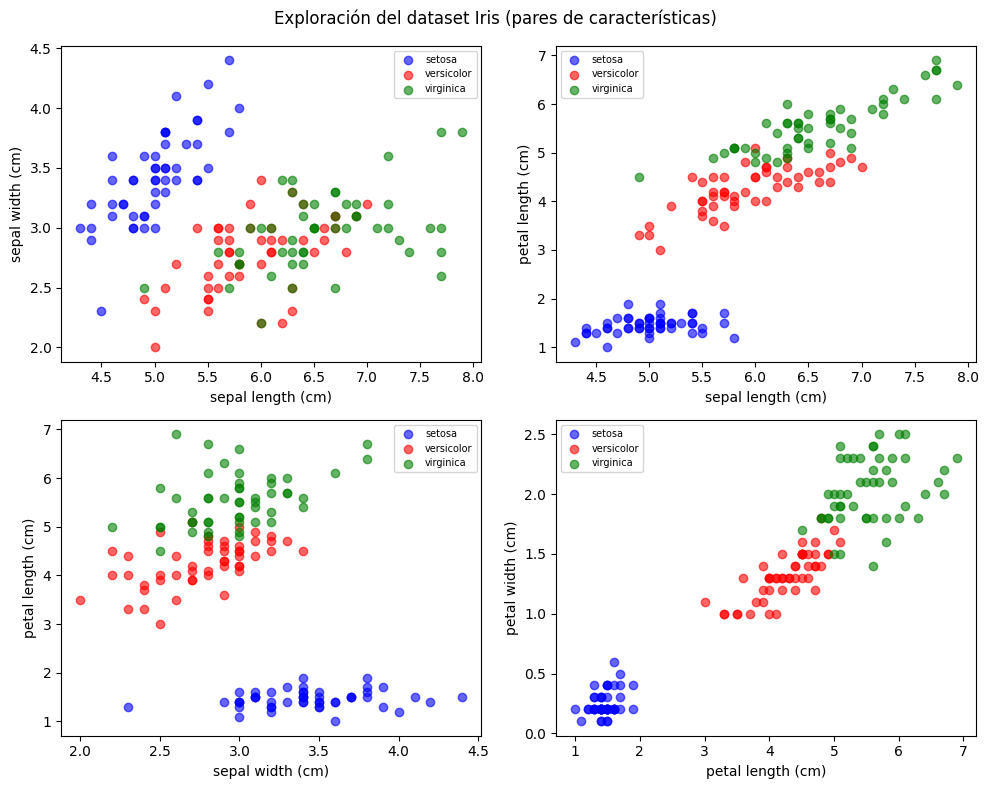

In [4]:

# ── 2. Intuición sobre el dataset Iris ───────────────────────────────────────
import pandas as pd

df = pd.DataFrame(X_iris, columns=iris.feature_names)
df["species"] = [iris.target_names[i] for i in y_iris]
print(df.describe())

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
pairs = [(0,1), (0,2), (1,2), (2,3)]
colors = ["blue", "red", "green"]

for ax, (i, j) in zip(axes.ravel(), pairs):
    for cls, color in zip(range(3), colors):
        mask = y_iris == cls
        ax.scatter(X_iris[mask, i], X_iris[mask, j],
                   c=color, label=iris.target_names[cls], alpha=0.6)
    ax.set_xlabel(iris.feature_names[i])
    ax.set_ylabel(iris.feature_names[j])
    ax.legend(fontsize=7)

plt.suptitle("Exploración del dataset Iris (pares de características)")
plt.tight_layout()
plt.show()


In [5]:

# ── 3. Dividir el dataset con train_test_split ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)
print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")


Entrenamiento: (120, 4), Prueba: (30, 4)


In [6]:

# ── 4. Entrenar DecisionTreeClassifier ───────────────────────────────────────
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

acc_train = clf.score(X_train, y_train)
acc_test  = clf.score(X_test,  y_test)
print(f"Exactitud entrenamiento : {acc_train:.3f}")
print(f"Exactitud prueba        : {acc_test:.3f}")


Exactitud entrenamiento : 0.983
Exactitud prueba        : 0.967


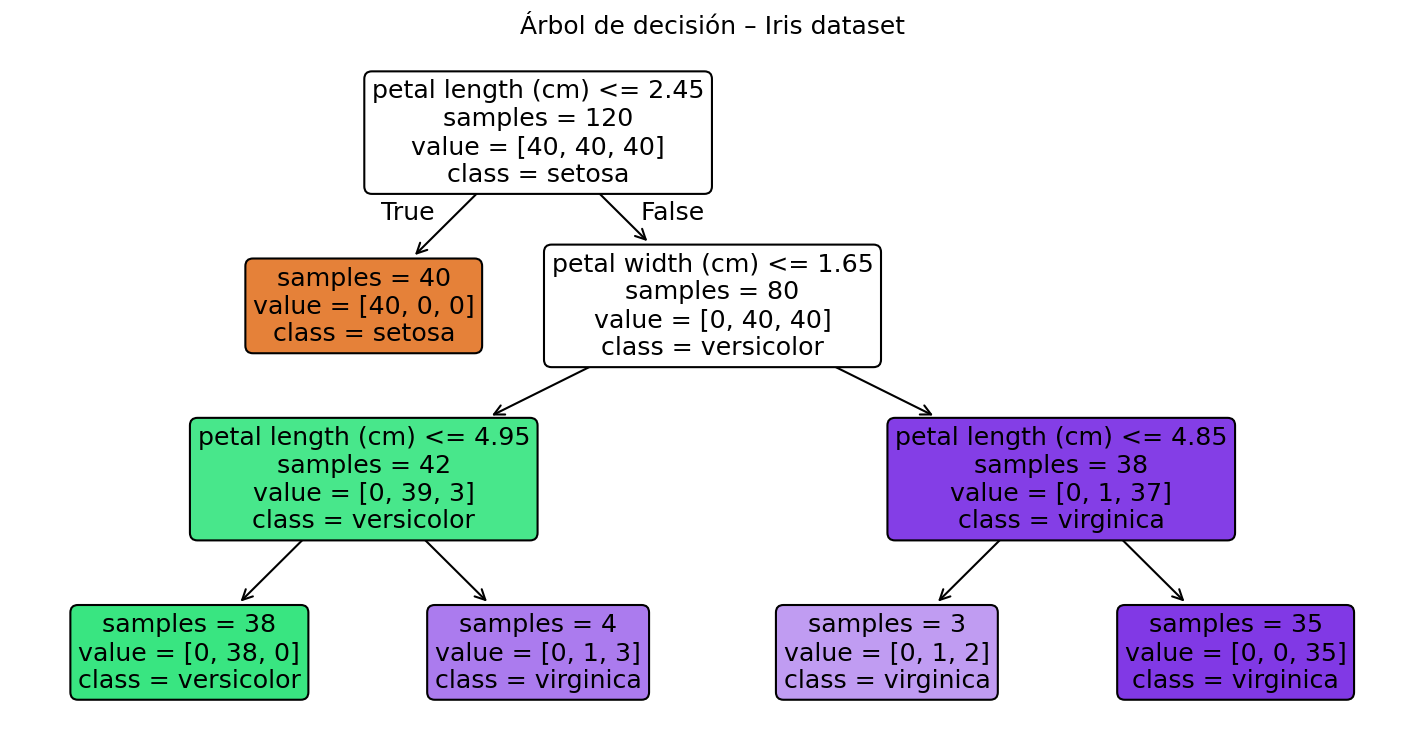

In [7]:

# ── 5. Gráfico del árbol de decisión ─────────────────────────────────────────
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12, 6), dpi=150)
tree.plot_tree(clf,
               class_names=iris.target_names,
               feature_names=iris.feature_names,
               impurity=False,
               filled=True,
               rounded=True,
               ax=axes)
plt.title("Árbol de decisión – Iris dataset")
plt.show()


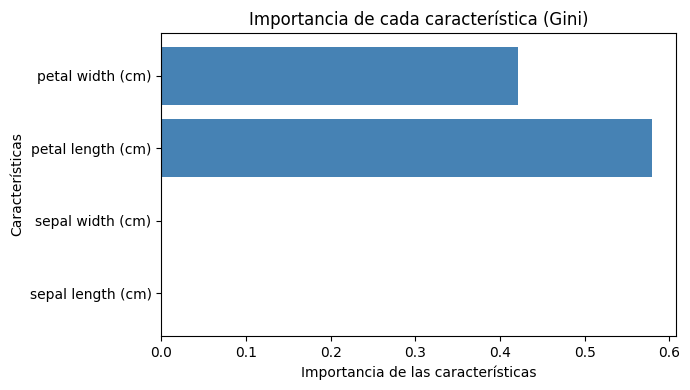

  sepal length (cm): 0.0000
  sepal width (cm): 0.0000
  petal length (cm): 0.5791
  petal width (cm): 0.4209


In [8]:

# ── 6. Importancia de las características ────────────────────────────────────
caract = iris.data.shape[1]
plt.figure(figsize=(7, 4))
plt.barh(range(caract), clf.feature_importances_, color="steelblue")
plt.yticks(np.arange(caract), iris.feature_names)
plt.xlabel("Importancia de las características")
plt.ylabel("Características")
plt.title("Importancia de cada característica (Gini)")
plt.tight_layout()
plt.show()

for name, imp in zip(iris.feature_names, clf.feature_importances_):
    print(f"  {name}: {imp:.4f}")


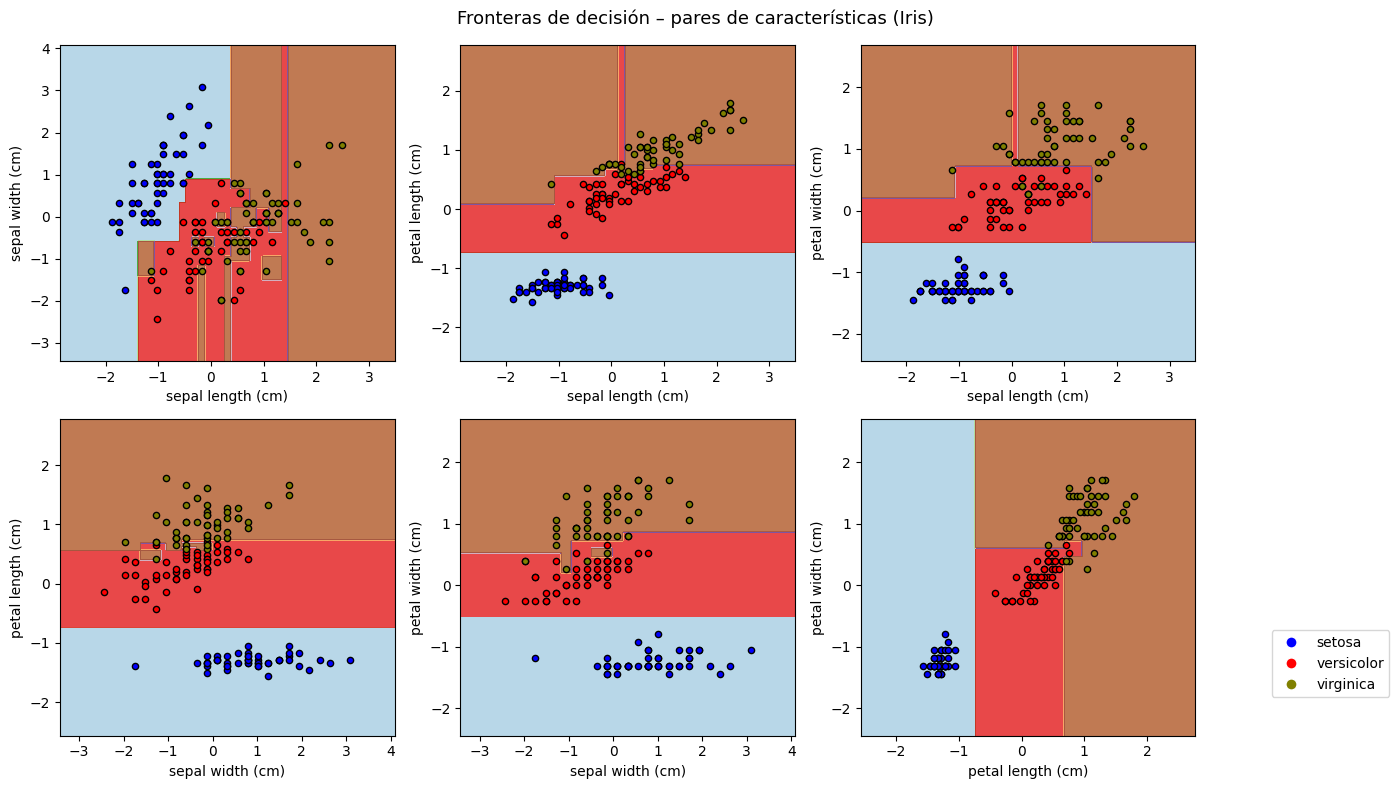

In [10]:

# ── 7. Fronteras de decisión (todos los pares de características) ─────────────
n_classes = 3
plot_colors = ["blue", "red", "olive"]
plot_step = 0.02

fig = plt.figure(figsize=(14, 8))

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],
                                 [1, 2], [1, 3], [2, 3]]):
    X = iris.data[:, pair]
    y = iris.target

    idx = np.arange(X.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)
    X = X[idx]
    y = y[idx]

    mean = X.mean(axis=0)
    std  = X.std(axis=0)
    X = (X - mean) / std

    clf_pair = DecisionTreeClassifier().fit(X, y)

    plt.subplot(2, 3, pairidx + 1)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    Z = clf_pair.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])
    plt.axis("tight")

    for i, color in zip(range(n_classes), plot_colors):
        mask = np.where(y == i)
        plt.scatter(X[mask, 0], X[mask, 1], color=color,
                    label=iris.target_names[i], edgecolors="k", s=20)

    plt.axis("tight")

plt.suptitle("Fronteras de decisión – pares de características (Iris)", fontsize=13)
handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=c, markersize=8, label=n)
           for c, n in zip(plot_colors, iris.target_names)]
plt.legend(handles=handles, loc="lower right", bbox_to_anchor=(1.6, 0.1))
plt.tight_layout()
plt.show()
